<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
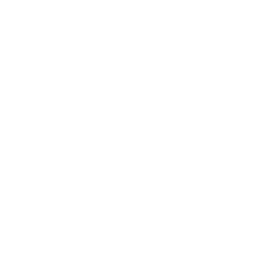
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">遺伝子発現からの分子サブタイプ分類</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; バイオテック／ゲノム腫瘍学 &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## エグゼクティブサマリー

腫瘍生検サンプルを、遺伝子発現バイオマーカーパネルを用いて 4 つの分子サブタイプ（Luminal-A、Luminal-B、HER2-enriched、Basal-like）に分類する。正準判別分析を適用して、高次元の発現空間を解釈可能な変動軸へと縮約する。MANOVA を用いて、平均発現プロファイルがサブタイプ間で有意に異なるかを検定する。交差検証により、治療経路選択の臨床意思決定支援に向けた分類の信頼性を推定する。

## データソース

| ソース | 説明 | レコード数 |
|--------|-------------|--------|
| WORK.GENE_EXPR | サブタイプラベル付きの腫瘍遺伝子発現 | 100 |
| WORK.NEW_BIOPSIES | 未分類の生検サンプル | 100 |


---

In [1]:
/* --------------------------------------------------------
   4 つの分子サブタイプを持つ合成遺伝子発現データセットを生成
   -------------------------------------------------------- */
データ work.gene_expr;
    呼出 streaminit(42);
    長さ mol_subtype $12;
    見出 mol_subtype='分子サブタイプ'
          tumor_id='腫瘍ID'
          esr1_expr='ESR1 発現量 (log2)'
          pgr_expr='PGR 発現量 (log2)'
          erbb2_expr='ERBB2 発現量 (log2)'
          ki67_expr='Ki67 発現量 (log2)'
          egfr_expr='EGFR 発現量 (log2)'
          cytokeratin5='サイトケラチン5 発現量 (log2)'
          tp53_mut_load='TP53 変異負荷'
          prolif_score='増殖スコア';
    配列 subtype_list[4] $12 _temporary_ ('LUMINAL_A' 'LUMINAL_B' 'HER2_ENRICH' 'BASAL_LIKE');
    繰返 sample_id = 1 から 100;
        tumor_id = cat('TUM-', PUT(sample_id, z5.));
        sub_idx = int(rand('uniform') * 4) + 1;
        mol_subtype = subtype_list[sub_idx];

        /* シミュレートした遺伝子発現マーカー（log2 スケール） */
        選択 (mol_subtype);
            場合 ('LUMINAL_A') 繰返;
                esr1_expr = round(rand('normal', 11.5, 1.2), 0.01);
                pgr_expr = round(rand('normal', 9.8, 1.5), 0.01);
                erbb2_expr = round(rand('normal', 7.2, 0.9), 0.01);
                ki67_expr = round(rand('normal', 6.0, 1.0), 0.01);
                egfr_expr = round(rand('normal', 6.5, 1.1), 0.01);
                cytokeratin5 = round(rand('normal', 5.0, 0.8), 0.01);
                tp53_mut_load = round(rand('poisson', 1.5), 1);
                prolif_score = round(rand('normal', 3.2, 0.8), 0.01);
            終了;
            場合 ('LUMINAL_B') 繰返;
                esr1_expr = round(rand('normal', 10.0, 1.4), 0.01);
                pgr_expr = round(rand('normal', 7.5, 1.8), 0.01);
                erbb2_expr = round(rand('normal', 8.5, 1.2), 0.01);
                ki67_expr = round(rand('normal', 8.5, 1.2), 0.01);
                egfr_expr = round(rand('normal', 7.0, 1.0), 0.01);
                cytokeratin5 = round(rand('normal', 5.5, 0.9), 0.01);
                tp53_mut_load = round(rand('poisson', 3.0), 1);
                prolif_score = round(rand('normal', 6.0, 1.0), 0.01);
            終了;
            場合 ('HER2_ENRICH') 繰返;
                esr1_expr = round(rand('normal', 6.5, 1.5), 0.01);
                pgr_expr = round(rand('normal', 5.0, 1.2), 0.01);
                erbb2_expr = round(rand('normal', 13.0, 1.0), 0.01);
                ki67_expr = round(rand('normal', 9.0, 1.3), 0.01);
                egfr_expr = round(rand('normal', 8.5, 1.2), 0.01);
                cytokeratin5 = round(rand('normal', 6.0, 1.0), 0.01);
                tp53_mut_load = round(rand('poisson', 5.0), 1);
                prolif_score = round(rand('normal', 7.5, 1.1), 0.01);
            終了;
            場合 ('BASAL_LIKE') 繰返;
                esr1_expr = round(rand('normal', 4.5, 1.3), 0.01);
                pgr_expr = round(rand('normal', 3.8, 1.0), 0.01);
                erbb2_expr = round(rand('normal', 6.0, 1.1), 0.01);
                ki67_expr = round(rand('normal', 10.5, 1.4), 0.01);
                egfr_expr = round(rand('normal', 11.0, 1.3), 0.01);
                cytokeratin5 = round(rand('normal', 10.5, 1.2), 0.01);
                tp53_mut_load = round(rand('poisson', 7.0), 1);
                prolif_score = round(rand('normal', 8.8, 1.2), 0.01);
            終了;
            その他;
        終了;
        出力;
    終了;
    削除 sub_idx;
実行;


NOTE: DATA work.gene_expr


NOTE: Wrote work.gene_expr (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   未分類の生検サンプルを生成
   -------------------------------------------------------- */
データ work.new_biopsies;
    呼出 streaminit(55);
    見出 mol_subtype='分子サブタイプ'
          tumor_id='腫瘍ID'
          esr1_expr='ESR1 発現量 (log2)'
          pgr_expr='PGR 発現量 (log2)'
          erbb2_expr='ERBB2 発現量 (log2)'
          ki67_expr='Ki67 発現量 (log2)'
          egfr_expr='EGFR 発現量 (log2)'
          cytokeratin5='サイトケラチン5 発現量 (log2)'
          tp53_mut_load='TP53 変異負荷'
          prolif_score='増殖スコア';
    繰返 sample_id = 5001 から 5100;
        tumor_id = cat('TUM-', PUT(sample_id, z5.));
        esr1_expr = round(rand('normal', 8.0, 3.0), 0.01);
        pgr_expr = round(rand('normal', 6.5, 3.0), 0.01);
        erbb2_expr = round(rand('normal', 8.5, 2.5), 0.01);
        ki67_expr = round(rand('normal', 8.0, 2.0), 0.01);
        egfr_expr = round(rand('normal', 8.0, 2.0), 0.01);
        cytokeratin5 = round(rand('normal', 7.0, 2.5), 0.01);
        tp53_mut_load = round(rand('poisson', 4.0), 1);
        prolif_score = round(rand('normal', 6.0, 2.5), 0.01);
        mol_subtype = '';
        出力;
    終了;
実行;


NOTE: DATA work.new_biopsies


NOTE: Wrote work.new_biopsies (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

                                                       分子サブタイプの分布                                                       

                                                   The FREQ Procedure

分子サブタイプ                  Frequency    Percent
----------------------------------------------
BASAL_LIKE                      24     24.00
HER2_ENRICH                     22     22.00
LUMINAL_A                       25     25.00
LUMINAL_B                       29     29.00
                                                   分子サブタイプ別 遺伝子発現サマリー                                                   

                                                  The MEANS Procedure

                                  Analysis Variable : esr1_expr ESR1 発現量 (log2)

        分子サブタイプ                        N Obs           Mean        Std Dev
        ------------------------------------------------------------------
        BASAL_LIKE                        24      4.5479167      1.2257100
        HER2_ENRICH                


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mol_subtype.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


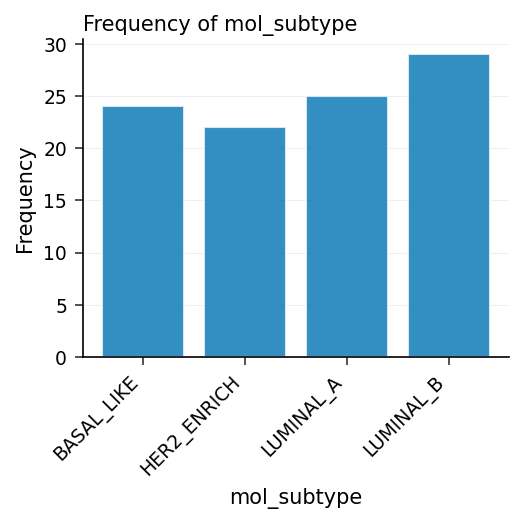

In [3]:
/* --------------------------------------------------------
   ベースラインのサブタイプ分布と発現プロファイル
   -------------------------------------------------------- */
処理 度数 データ=work.gene_expr;
    TABLES mol_subtype / nocum;
    見出 mol_subtype='分子サブタイプ';
    表題 '分子サブタイプの分布';
実行;

処理 平均 データ=work.gene_expr n mean std;
    分類 mol_subtype;
    変数 esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    見出 mol_subtype='分子サブタイプ'
          esr1_expr='ESR1 発現量 (log2)'
          pgr_expr='PGR 発現量 (log2)'
          erbb2_expr='ERBB2 発現量 (log2)'
          ki67_expr='Ki67 発現量 (log2)'
          egfr_expr='EGFR 発現量 (log2)'
          cytokeratin5='サイトケラチン5 発現量 (log2)'
          tp53_mut_load='TP53 変異負荷'
          prolif_score='増殖スコア';
    表題 '分子サブタイプ別 遺伝子発現サマリー';
実行;

---

In [4]:
/* --------------------------------------------------------
   MANOVA 付き正準判別分析
   CANONICAL は可視化のための判別軸を抽出する。
   MANOVA はサブタイプ間の全体的な平均分離を検定する。
   -------------------------------------------------------- */
処理 DISCRIM データ=work.gene_expr
        METHOD=NORMAL
        pool=TEST
        canonical
        MANOVA
        crossvalidate
        out=work.subtype_canonical
        OUTSTAT=work.subtype_stats;
    分類 mol_subtype;
    変数 esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    PRIORS equal;
    見出 mol_subtype='分子サブタイプ'
          esr1_expr='ESR1 発現量 (log2)'
          pgr_expr='PGR 発現量 (log2)'
          erbb2_expr='ERBB2 発現量 (log2)'
          ki67_expr='Ki67 発現量 (log2)'
          egfr_expr='EGFR 発現量 (log2)'
          cytokeratin5='サイトケラチン5 発現量 (log2)'
          tp53_mut_load='TP53 変異負荷'
          prolif_score='増殖スコア';
    表題 '正準判別分析：腫瘍分子サブタイプ';
    title2 'MANOVA：平均発現プロファイル差の検定';
実行;

                                                   分子サブタイプ別 遺伝子発現サマリー                                                   


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Cross-Validation Error Rate: 0.0400
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: Multivariate Statistics:
NOTE:   Wilks' Lambda: 0.0037 (p = 0.000000)
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


---

                                                   分子サブタイプ別 遺伝子発現サマリー                                                   




NOTE: PROC SGPLOT data=work.subtype_canonical

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


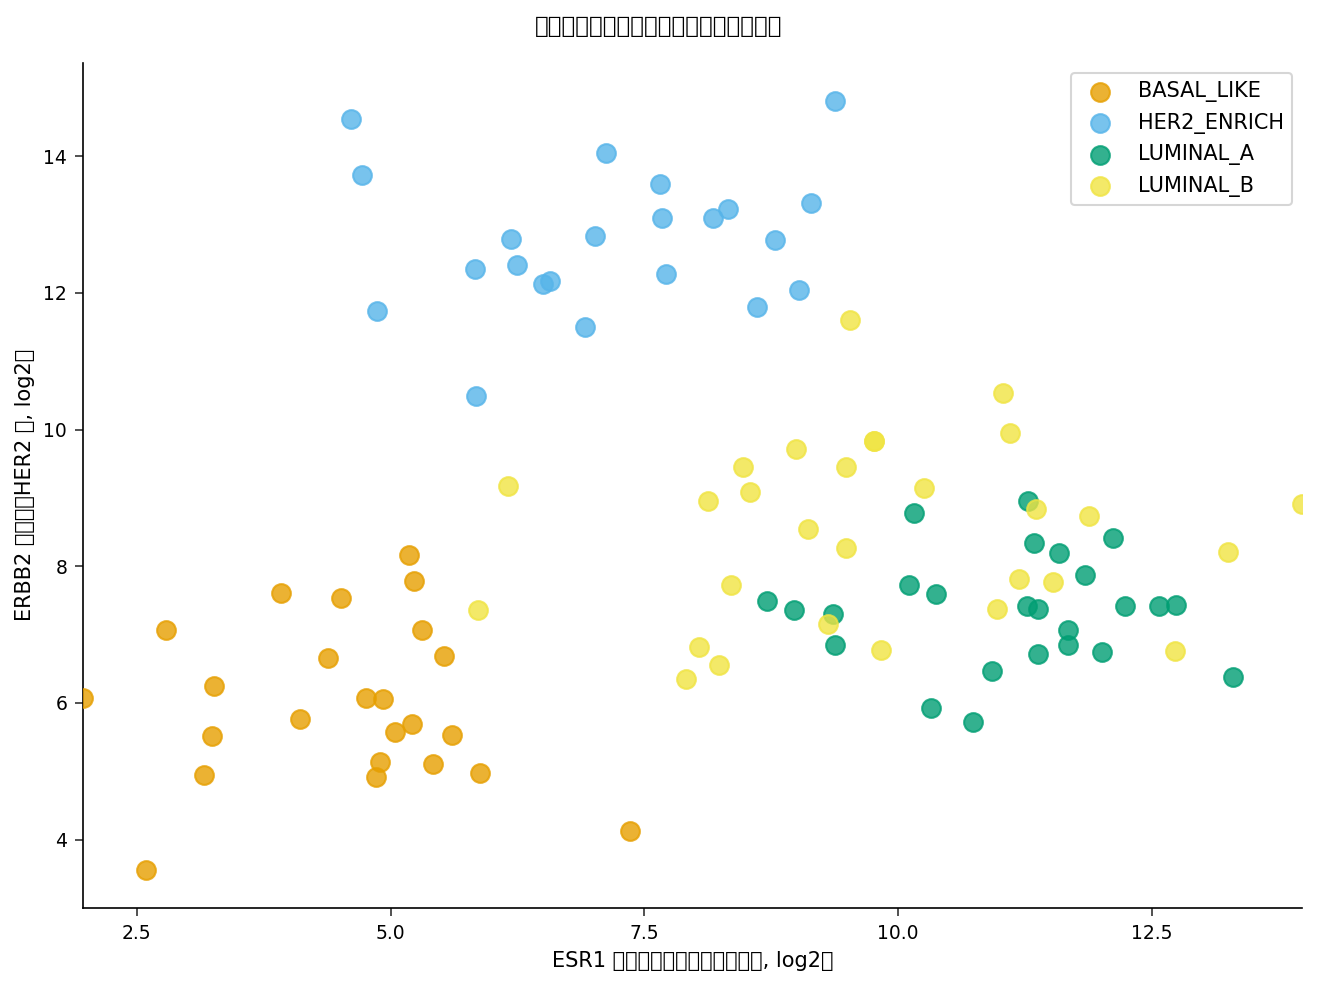

In [5]:
/* --------------------------------------------------------
   発現空間におけるサブタイプ分離
   ESR1（ホルモン受容体軸）対 ERBB2（HER2 軸）、
   判別分析の OUT= データセットから描画する。
   -------------------------------------------------------- */
処理 SGPLOT データ=work.subtype_canonical;
    SCATTER x=esr1_expr y=erbb2_expr / GROUP=mol_subtype
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.2;
    XAXIS 見出='ESR1 発現量（ホルモン受容体軸, log2）';
    YAXIS 見出='ERBB2 発現量（HER2 軸, log2）';
    表題 '発現空間における分子サブタイプの分離';
実行;


In [6]:
/* --------------------------------------------------------
   未分類の生検サンプルを分類する
   -------------------------------------------------------- */
処理 DISCRIM データ=work.gene_expr
        testdata=work.new_biopsies
        testout=work.classified_biopsies
        METHOD=NORMAL
        pool=TEST
        canonical;
    分類 mol_subtype;
    変数 esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    PRIORS equal;
    見出 mol_subtype='分子サブタイプ'
          esr1_expr='ESR1 発現量 (log2)'
          pgr_expr='PGR 発現量 (log2)'
          erbb2_expr='ERBB2 発現量 (log2)'
          ki67_expr='Ki67 発現量 (log2)'
          egfr_expr='EGFR 発現量 (log2)'
          cytokeratin5='サイトケラチン5 発現量 (log2)'
          tp53_mut_load='TP53 変異負荷'
          prolif_score='増殖スコア';
    表題 '新規生検の分子サブタイプ分類';
実行;

                                                   分子サブタイプ別 遺伝子発現サマリー                                                   


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


                                                    予測分子サブタイプ分布：新規生検                                                    

                                                   The FREQ Procedure

予測分子サブタイプ                      Frequency    Percent
----------------------------------------------------
BASAL_LIKE                             7      7.00
HER2_ENRICH                           47     47.00
LUMINAL_A                             10     10.00
LUMINAL_B                             36     36.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq__into_.spec.json
NOTE: PROC FREQ statement used.


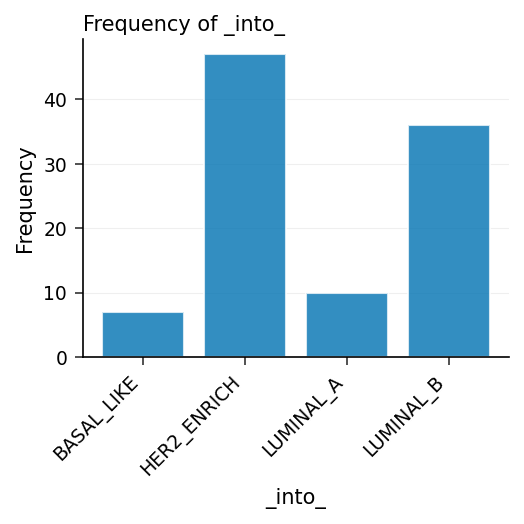

In [7]:
/* --------------------------------------------------------
   新規生検の分類分布
   -------------------------------------------------------- */
処理 度数 データ=work.classified_biopsies;
    TABLES _into_ / nocum;
    見出 _into_='予測分子サブタイプ';
    表題 '予測分子サブタイプ分布：新規生検';
実行;

---

### 解釈

MANOVA 検定により、4 つの分子サブタイプ間で平均遺伝子発現プロファイルに極めて有意な差があることが確認される：Wilks の Lambda = 0.0037、p < 0.0001 であり、サブタイプは 8 マーカーの発現空間で明確に異なる領域を占める。その分離は発現空間の散布図にも表れており、Luminal 腫瘍は ESR1（ホルモン受容体）軸で高く位置し、HER2-enriched 腫瘍は ERBB2 軸の上端へ押し上げられ、Basal-like 腫瘍は両軸の左下に落ちる。ラベル付き 100 腫瘍の再代入分類は完璧（見かけの誤り 0%）で、1 個抜き交差検証では誤り率はわずか 4%――正直な交差検証精度 96% であり、交差検証済み混同行列ではすべてのサブタイプが正しく復元されている。学習済み分類器を 100 個の未ラベル生検に適用すると、47 個が HER2-enriched、36 個が Luminal-B、10 個が Luminal-A、7 個が Basal-like に割り当てられる。HER2-enriched への偏りは、この生検パネルで ERBB2 と増殖指標が高いことを反映している。これらのサブタイプ判定は治療経路の選択を左右する：Luminal 腫瘍には内分泌療法、HER2-enriched 群には抗 HER2 標的薬、Basal-like 腫瘍には化学療法レジメンである。


---

In [8]:
/* --------------------------------------------------------
   治療計画のため分類済み生検をエクスポート
   -------------------------------------------------------- */
処理 EXPORT データ=work.classified_biopsies
    OUTFILE='classified_biopsy_subtypes.csv'
    DBMS=csv REPLACE;
実行;

処理 EXPORT データ=work.subtype_canonical
    OUTFILE='canonical_subtype_scores.csv'
    DBMS=csv REPLACE;
実行;


NOTE: PROC EXPORT data=work.classified_biopsies outfile=classified_biopsy_subtypes.csv

NOTE: Exported 100 rows to classified_biopsy_subtypes.csv.
NOTE: PROC EXPORT data=work.subtype_canonical outfile=canonical_subtype_scores.csv

NOTE: Exported 100 rows to canonical_subtype_scores.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 機密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
提供： <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>